# Echo State Network (ESN) for Chaotic Time Series Prediction

This notebook demonstrates how to use **ReservoirPy** to build an Echo State Network
that learns and predicts chaotic time series data.

**Package:** `reservoirpy` (v0.4+)  
**Install:** `pip install reservoirpy`

---

## Background

An Echo State Network is a type of recurrent neural network where:
- The **input weights** and **recurrent (reservoir) weights** are randomly initialized and **never trained**.
- Only the **output (readout) weights** are trained, typically via simple linear regression.

This makes ESNs extremely efficient for learning temporal/sequential data, including chaotic systems,
because the reservoir acts as a high-dimensional nonlinear kernel that projects the input into a
rich feature space from which a linear readout can extract the relevant dynamics.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from reservoirpy.nodes import Reservoir, Ridge
import reservoirpy

# Reproducibility
reservoirpy.set_seed(42)
np.random.seed(42)

print(f"ReservoirPy version: {reservoirpy.__version__}")

ReservoirPy version: 0.4.1


---
## Step 1: Generate Chaotic Time Series Data

We use the **Mackey-Glass** delay differential equation, a standard benchmark for chaotic time series:

$$\frac{dx}{dt} = \beta \frac{x(t-\tau)}{1 + x(t-\tau)^{10}} - \gamma\, x(t)$$

with $\beta = 0.2$, $\gamma = 0.1$, and delay $\tau = 17$. For $\tau > 17$ the system is chaotic.

We integrate this with a simple Euler method to produce a discrete time series.

**Why Mackey-Glass?** It produces deterministic chaos (sensitive dependence on initial conditions,
positive Lyapunov exponent) and is widely used in the reservoir computing literature, making
results directly comparable to published work.

In [2]:
def mackey_glass(n_steps, tau=17, beta=0.2, gamma=0.1, n=10, dt=1.0, x0=1.2, warmup=500):
    """
    Generate the Mackey-Glass chaotic time series.
    
    Parameters
    ----------
    n_steps : int
        Number of time steps to generate.
    tau : int
        Delay parameter. tau > 17 gives chaos.
    beta, gamma, n : float
        Equation parameters.
    dt : float
        Integration step size.
    x0 : float
        Initial condition.
    warmup : int
        Transient steps to discard.
    
    Returns
    -------
    x : ndarray of shape (n_steps, 1)
        The chaotic time series.
    """
    total = n_steps + warmup
    history_len = tau + 1
    
    # Initialize history with the initial condition
    x_history = np.ones(history_len) * x0
    x_t = x0
    series = np.zeros(total)
    
    for t in range(total):
        x_delayed = x_history[0]  # x(t - tau)
        dx = beta * x_delayed / (1.0 + x_delayed**n) - gamma * x_t
        x_t = x_t + dt * dx
        
        # Shift the history buffer
        x_history = np.roll(x_history, -1)
        x_history[-1] = x_t
        series[t] = x_t
    
    # Discard warmup transient, reshape to (n_steps, 1) as required by ReservoirPy
    return series[warmup:].reshape(-1, 1)


# Generate 5000 data points
data = mackey_glass(n_steps=5000, tau=17)

print(f"Data shape: {data.shape}")
print(f"Min: {data.min():.4f}, Max: {data.max():.4f}, Std: {data.std():.4f}")

Data shape: (5000, 1)
Min: 0.3696, Max: 1.3436, Std: 0.2354


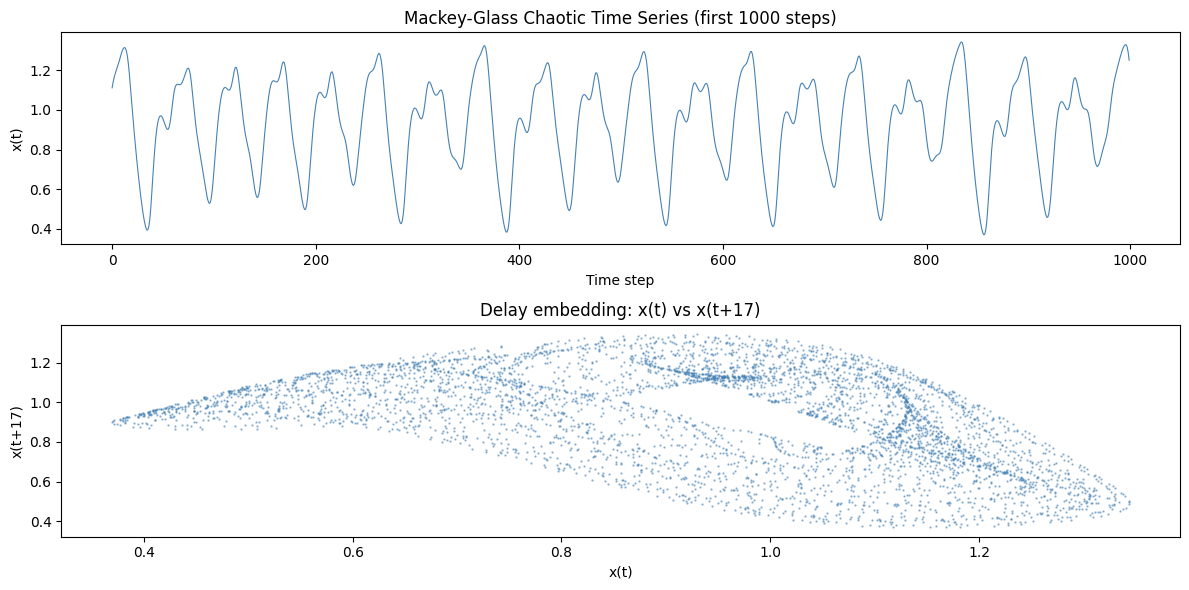

In [3]:
# Visualize the chaotic time series
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

axes[0].plot(data[:1000], color='steelblue', linewidth=0.8)
axes[0].set_title('Mackey-Glass Chaotic Time Series (first 1000 steps)')
axes[0].set_xlabel('Time step')
axes[0].set_ylabel('x(t)')

# Delay embedding to show the attractor
delay = 17
axes[1].scatter(data[:-delay, 0], data[delay:, 0], s=0.5, alpha=0.5, color='steelblue')
axes[1].set_title(f'Delay embedding: x(t) vs x(t+{delay})')
axes[1].set_xlabel('x(t)')
axes[1].set_ylabel(f'x(t+{delay})')

plt.tight_layout()
plt.show()

---
## Step 2: Prepare Train/Test Split

For time series prediction, the task is: given $x(t)$, predict $x(t+1)$.

- **Input:** $x(t)$ at each time step
- **Target:** $x(t+1)$ (one-step-ahead prediction)

We use the first 80% for training and the last 20% for testing.
No shuffling — temporal order must be preserved for sequential data.

In [5]:
# One-step-ahead prediction: input x(t), target x(t+1)
X = data[:-1]   # x(t)     : shape (4999, 1)
Y = data[1:]    # x(t+1)   : shape (4999, 1)

# Train/test split (80/20)
train_len = int(0.8 * len(X))

X_train, Y_train = X[:train_len], Y[:train_len]
X_test,  Y_test  = X[train_len:], Y[train_len:]

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

Training samples: 3999
Testing samples:  1000


---
## Step 3: Build the ESN

An ESN consists of two components:

### 3a. The Reservoir

A large recurrent neural network with fixed (untrained) weights. At each time step $t$:

$$\mathbf{r}(t) = (1-\alpha)\,\mathbf{r}(t-1) + \alpha\,\tanh\!\big(\mathbf{W}_{\text{in}}\,\mathbf{x}(t) + \mathbf{W}\,\mathbf{r}(t-1)\big)$$

where:
- $\mathbf{r}(t) \in \mathbb{R}^N$ is the reservoir state vector ($N$ = number of reservoir units)
- $\mathbf{W}_{\text{in}} \in \mathbb{R}^{N \times d}$ is the input weight matrix (random, fixed)
- $\mathbf{W} \in \mathbb{R}^{N \times N}$ is the recurrent weight matrix (random, fixed)
- $\alpha$ is the **leaking rate** (controls memory vs. reactivity)
- $\tanh$ is the **activation function**

**Key hyperparameters:**

| Parameter | Symbol | Role |
|-----------|--------|------|
| `units` | $N$ | Number of reservoir neurons. Larger = more expressive, but slower. |
| `sr` (spectral radius) | $\rho(\mathbf{W})$ | Largest eigenvalue magnitude of $\mathbf{W}$. Controls how long information persists in the reservoir. For chaotic data, typically $\rho \approx 0.9$–$0.99$. Must be $< 1$ for the **echo state property** (fading memory). |
| `lr` (leaking rate) | $\alpha$ | Interpolates between the previous state and the new activation. $\alpha = 1$: no leaking (fast dynamics). $\alpha \ll 1$: slow dynamics, long memory. |
| `input_scaling` | — | Scales $\mathbf{W}_{\text{in}}$. Controls how strongly inputs drive the reservoir. |
| `rc_connectivity` | — | Sparsity of $\mathbf{W}$. Sparse reservoirs are computationally cheaper and often perform well. |

**Why $\tanh$ activation?**  
$\tanh$ is bounded in $[-1, 1]$, ensuring reservoir states don't explode. It introduces the nonlinearity
needed to represent complex dynamics. It's the standard choice in ESN literature and works well
for most applications.

### 3b. The Readout (Ridge Regression)

A simple linear layer trained to map reservoir states to predictions:

$$\hat{\mathbf{y}}(t) = \mathbf{W}_{\text{out}}\,\mathbf{r}(t)$$

The readout weights $\mathbf{W}_{\text{out}}$ are found by **Ridge regression** (Tikhonov regularization):

$$\mathbf{W}_{\text{out}} = \mathbf{Y}^T \mathbf{R} \,(\mathbf{R}^T \mathbf{R} + \lambda \mathbf{I})^{-1}$$

where $\mathbf{R}$ is the matrix of collected reservoir states, $\mathbf{Y}$ is the target matrix, and $\lambda$
is the **regularization coefficient**.

**Why Ridge regression (not ordinary least squares)?**  
- The reservoir state matrix $\mathbf{R}$ can be ill-conditioned (nearly collinear columns) because
  reservoir neurons are randomly connected.
- Ridge adds $\lambda \mathbf{I}$ to stabilize the inversion, preventing overfitting.
- It's equivalent to an $\ell_2$ penalty on $\mathbf{W}_{\text{out}}$, which keeps weights small and
  improves generalization — especially important for chaotic data where overfitting means
  the model memorizes noise rather than learning the underlying attractor.
- It has a **closed-form solution** (no iterative optimization), making training instantaneous.

In [8]:
# --- Reservoir ---
reservoir = Reservoir(
    units=500,           # N = 500 reservoir neurons
    sr=0.95,             # Spectral radius: close to 1 for chaotic data (long memory)
    lr=0.3,              # Leaking rate: moderate, balances fast and slow dynamics
    input_scaling=0.1,   # Scale inputs modestly (data is already ~O(1))
    rc_connectivity=0.1, # 10% connectivity: sparse reservoir (efficient, avoids redundancy)
    seed=42
)

# --- Readout (Ridge Regression) ---
readout = Ridge(
    ridge=1e-6           # Regularization coefficient lambda
                         # Small value: data is clean (no noise), so we need little regularization
                         # For noisy data, increase this (e.g., 1e-4 to 1e-2)
)

# --- Connect them: Reservoir >> Readout ---
# The >> operator chains the reservoir output into the readout input
esn = reservoir >> readout

print("ESN architecture:")
print(f"  Reservoir: {reservoir.units} units, sr={reservoir.sr}, lr={reservoir.lr}")
print(f"  Readout:   Ridge regression, lambda={readout.ridge}")
print(f"  Total trainable parameters: {reservoir.units} x 1 = {reservoir.units} (readout weights only)")
print(f"  Total FIXED parameters: ~{reservoir.units**2 * 0.1 + reservoir.units:.0f} (reservoir weights)")

ESN architecture:
  Reservoir: 500 units, sr=0.95, lr=0.3
  Readout:   Ridge regression, lambda=1e-06
  Total trainable parameters: 500 x 1 = 500 (readout weights only)
  Total FIXED parameters: ~25500 (reservoir weights)


---
## Step 4: Train the ESN

Training an ESN is a two-phase process:

1. **Run the reservoir** on training data to collect internal states $\mathbf{R} = [\mathbf{r}(1), \ldots, \mathbf{r}(T)]$.
   This is a forward pass — no gradients, no backpropagation.

2. **Solve Ridge regression** to find $\mathbf{W}_{\text{out}}$ that maps states to targets.
   This is a single matrix operation.

The `warmup` parameter discards the first few reservoir states. This is necessary because
the reservoir starts from zero state $\mathbf{r}(0) = \mathbf{0}$ and needs a few steps to "wash in"
— to forget its initial condition and reflect the actual input history. For chaotic systems,
100–200 steps is typically sufficient.

In [9]:
# Train the ESN
# warmup=100: discard first 100 reservoir states (transient wash-in period)
predictions_train = esn.fit(X_train, Y_train, warmup=100)

print("Training complete!")
print("(Reservoir states collected + Ridge regression solved in one call)")

Training complete!
(Reservoir states collected + Ridge regression solved in one call)


---
## Step 5: Test — One-Step-Ahead Prediction

We feed the true $x(t)$ at each test step and predict $\hat{x}(t+1)$.
This tests whether the ESN has learned the map $x(t) \mapsto x(t+1)$.

We measure performance with:
- **NRMSE** (Normalized Root Mean Square Error): $\text{NRMSE} = \frac{\text{RMSE}}{\sigma_y}$
  where $\sigma_y$ is the standard deviation of the target. NRMSE $\ll 1$ means the model
  is much better than predicting the mean.

In [10]:
# One-step-ahead prediction on test set
Y_pred = esn.run(X_test)

# Convert to arrays
Y_pred = np.array(Y_pred).reshape(-1, 1)

# Compute error metrics
rmse = np.sqrt(np.mean((Y_test - Y_pred)**2))
nrmse = rmse / np.std(Y_test)

print(f"One-step-ahead prediction:")
print(f"  RMSE:  {rmse:.6f}")
print(f"  NRMSE: {nrmse:.6f}")

One-step-ahead prediction:
  RMSE:  0.003276
  NRMSE: 0.014074


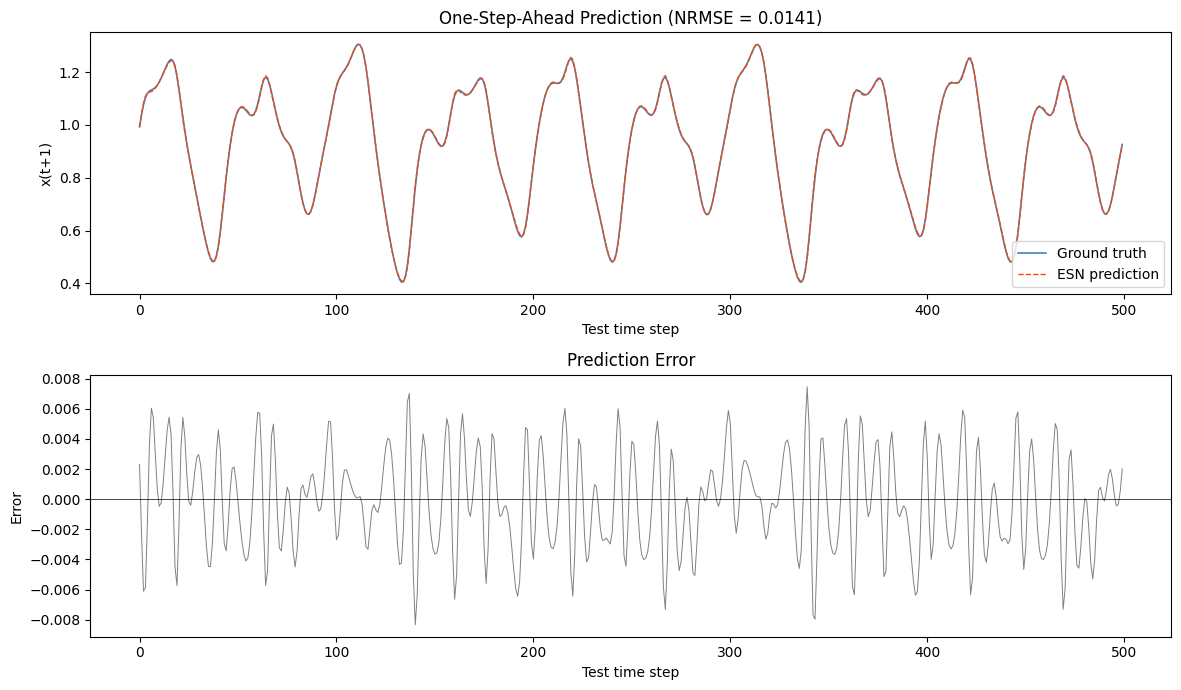

In [11]:
# Visualize one-step-ahead prediction
fig, axes = plt.subplots(2, 1, figsize=(12, 7))

# Top: overlay prediction and ground truth
t_plot = 500  # show first 500 test steps for clarity
axes[0].plot(Y_test[:t_plot], label='Ground truth', color='steelblue', linewidth=1.2)
axes[0].plot(Y_pred[:t_plot], label='ESN prediction', color='orangered', linewidth=1.0, linestyle='--')
axes[0].set_title(f'One-Step-Ahead Prediction (NRMSE = {nrmse:.4f})')
axes[0].set_xlabel('Test time step')
axes[0].set_ylabel('x(t+1)')
axes[0].legend()

# Bottom: prediction error
error = Y_test[:t_plot] - Y_pred[:t_plot]
axes[1].plot(error, color='gray', linewidth=0.7)
axes[1].axhline(y=0, color='black', linewidth=0.5)
axes[1].set_title('Prediction Error')
axes[1].set_xlabel('Test time step')
axes[1].set_ylabel('Error')

plt.tight_layout()
plt.show()

---
## Step 6: Free-Run (Autonomous) Prediction

The real test of learning chaotic dynamics: **feed the ESN's own prediction back as input**
and let it generate a time series autonomously.

$$\hat{x}(t+1) = \text{ESN}(\hat{x}(t))$$

For chaotic systems, small errors grow exponentially (positive Lyapunov exponent),
so the free-run trajectory will eventually diverge from the true trajectory. However,
a good ESN should:
1. Track the true trajectory for many Lyapunov times
2. Reproduce the correct **attractor structure** even after divergence

In [12]:
# Free-run prediction
n_freerun = 500

# First, warm up the reservoir with some true data to set the internal state
warmup_data = X_test[:200]
_ = esn.run(warmup_data)

# Now do free-run: feed prediction back as input
freerun_preds = []
current_input = X_test[200:201]  # start from a true data point

for step in range(n_freerun):
    pred = esn.run(current_input)  # predict next step
    pred = np.array(pred).reshape(1, -1)
    freerun_preds.append(pred[0, 0])
    current_input = pred            # feed prediction back

freerun_preds = np.array(freerun_preds)
freerun_truth = Y_test[200:200+n_freerun, 0]

print(f"Free-run generated {n_freerun} autonomous steps")

Free-run generated 500 autonomous steps


In [16]:
# Convert to arrays
freerun_preds = np.array(freerun_preds).reshape(-1, 1)

# Compute error metrics
rmse = np.sqrt(np.mean((freerun_truth - freerun_preds)**2))
nrmse = rmse / np.std(freerun_truth)

print(f"Free-run prediction:")
print(f"  RMSE:  {rmse:.6f}")
print(f"  NRMSE: {nrmse:.6f}")

Free-run prediction:
  RMSE:  0.315713
  NRMSE: 1.383547


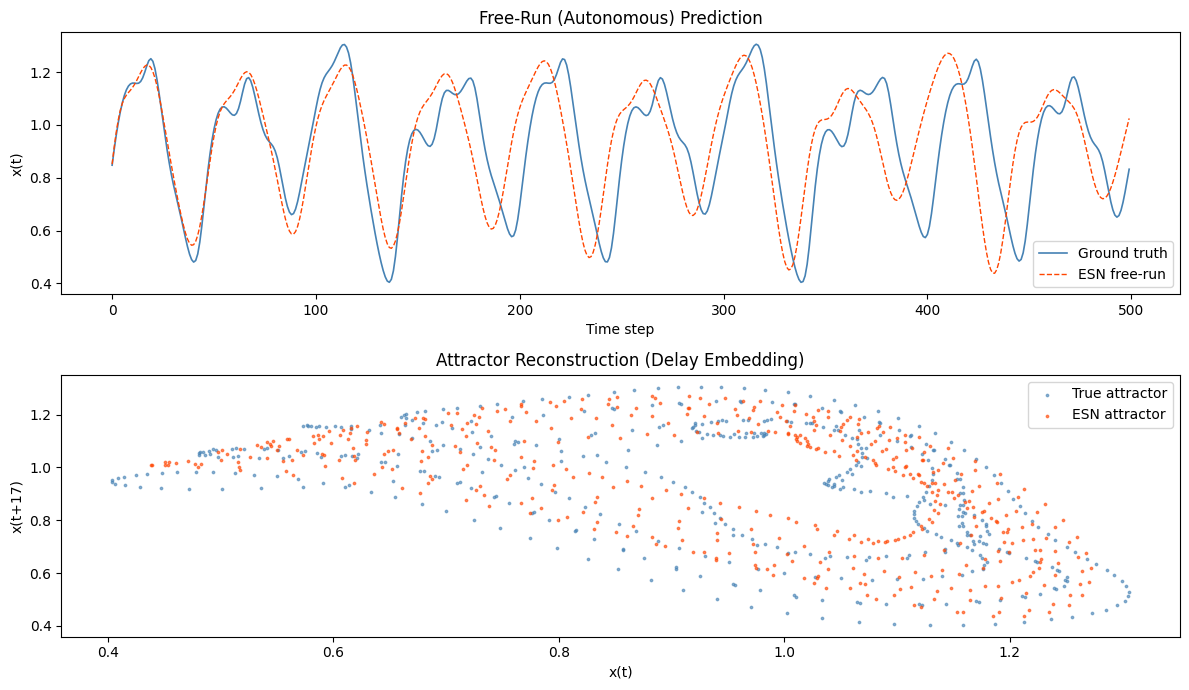

In [17]:
# Visualize free-run prediction
fig, axes = plt.subplots(2, 1, figsize=(12, 7))

# Time series comparison
axes[0].plot(freerun_truth, label='Ground truth', color='steelblue', linewidth=1.2)
axes[0].plot(freerun_preds, label='ESN free-run', color='orangered', linewidth=1.0, linestyle='--')
axes[0].set_title('Free-Run (Autonomous) Prediction')
axes[0].set_xlabel('Time step')
axes[0].set_ylabel('x(t)')
axes[0].legend()

# Attractor comparison via delay embedding
delay = 17
axes[1].scatter(freerun_truth[:-delay], freerun_truth[delay:], s=3, alpha=0.6, 
                label='True attractor', color='steelblue')
axes[1].scatter(freerun_preds[:-delay], freerun_preds[delay:], s=3, alpha=0.6, 
                label='ESN attractor', color='orangered')
axes[1].set_title('Attractor Reconstruction (Delay Embedding)')
axes[1].set_xlabel('x(t)')
axes[1].set_ylabel(f'x(t+{delay})')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Step 7: Inspect Reservoir Dynamics

Let's look inside the reservoir to understand what it's doing.
The reservoir states form a high-dimensional representation of the input history.

Reservoir states shape: (500, 500)
  (500 time steps x 500 neurons)


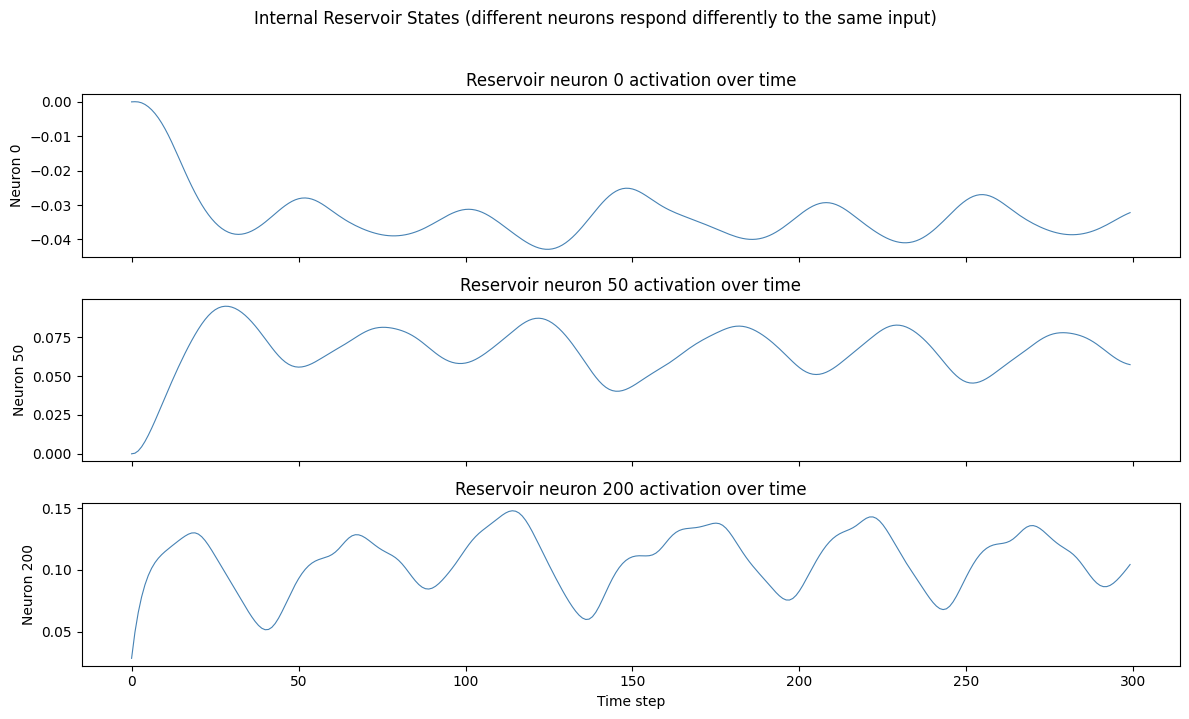

In [14]:
# Collect reservoir states for a portion of the test data
# Reset reservoir state first
reservoir.reset()
states = reservoir.run(X_test[:500])
states = np.array(states)

print(f"Reservoir states shape: {states.shape}")
print(f"  (500 time steps x {reservoir.units} neurons)")

# Plot a few reservoir neurons
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

for i, neuron_idx in enumerate([0, 50, 200]):
    axes[i].plot(states[:300, neuron_idx], linewidth=0.8, color='steelblue')
    axes[i].set_ylabel(f'Neuron {neuron_idx}')
    axes[i].set_title(f'Reservoir neuron {neuron_idx} activation over time')

axes[-1].set_xlabel('Time step')
plt.suptitle('Internal Reservoir States (different neurons respond differently to the same input)', 
             y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

---
## Summary of the ESN Pipeline

| Stage | What happens | Trainable? |
|-------|-------------|------------|
| **Input → Reservoir** | Input scaled by random $\mathbf{W}_{\text{in}}$, mixed with recurrent state via $\tanh$ nonlinearity | No |
| **Reservoir recurrence** | State $\mathbf{r}(t)$ updated with leaking rate $\alpha$, spectral radius $\rho$ controls memory | No |
| **Reservoir → Readout** | Linear mapping $\mathbf{W}_{\text{out}} \mathbf{r}(t)$, solved by Ridge regression | **Yes** |

### Why this works for chaos:
1. **High dimensionality**: 500 reservoir neurons project the 1D input into a 500D space, making nonlinear patterns linearly separable.
2. **Fading memory (echo state property)**: The reservoir "remembers" recent inputs but forgets distant past — matching the short-term predictability of chaotic systems.
3. **Spectral radius near 1**: Ensures the reservoir operates at the "edge of chaos" where its computational power is maximal.
4. **Ridge regression**: Robust, closed-form solution that avoids overfitting the chaotic (noisy-looking) training signal.

### Adapting to your own data:
```python
# Replace the Mackey-Glass data with your own chaotic time series:
data = np.loadtxt('your_data.csv').reshape(-1, 1)  # shape (T, 1)
# Then follow the same train/test split and ESN pipeline above.
```

### Hyperparameter tuning tips:
- **Noisy data?** Increase `ridge` (e.g., 1e-3 to 1e-1)
- **Slow dynamics?** Decrease `lr` (leaking rate)
- **Complex attractor?** Increase `units` (reservoir size)
- **Short memory needed?** Decrease `sr` (spectral radius)